In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\286915373.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')


Extracting the data for a given grid id

In [4]:
specific_key = 'G124'
all_band_values = {}
print(type(specific_key))
for grid_data in data[specific_key]:
    for band_key, band_data in grid_data.items():
       if band_key.startswith('fb_'):
            if band_key in all_band_values:
                all_band_values[band_key].append(band_data)
            else:
                all_band_values[band_key] = [band_data]

data = []
for band_key, band_values in all_band_values.items():
    datetime_values = [entry['datetime'] for entry in band_values]
    q1_values = [entry['Q1'] for entry in band_values]
    q2_values = [entry['Q2'] for entry in band_values]
    q3_values = [entry['Q3'] for entry in band_values]
    
    
    for datetime_val, q1_val, q2_val, q3_val in zip(datetime_values, q1_values, q2_values, q3_values):
        data.append({'datetime': datetime_val,'band_key': band_key, 'Q1': q1_val, 'Q2': q2_val, 'Q3': q3_val})

df = pd.DataFrame(data)


<class 'str'>


In [4]:
df

,datetime,band_key,Q1,Q2,Q3
0,2005-01-01 01:49:45.246,fb_1,-0.828218,-0.749787,-0.632140
1,2005-01-01 01:51:48.126,fb_1,-0.857630,-0.789002,-0.671355
2,2005-01-01 01:53:51.006,fb_1,-0.906649,-0.828218,-0.710571
3,2005-01-02 02:36:47.531,fb_1,-1.024296,-0.906649,-0.769394
4,2005-01-07 01:26:17.018,fb_1,-1.063512,-0.965473,-0.789002
...,...,...,...,...,...
41883,2009-12-30 01:05:47.402,fb_11,-2.470195,-2.241991,-1.696368
41884,2009-12-30 01:07:50.282,fb_11,-2.596994,-2.510518,-2.243183
41885,2009-12-31 01:33:45.656,fb_11,-2.442166,-2.110694,-1.674310
41886,2009-12-31 01:35:48.536,fb_11,-2.584284,-2.361352,-1.370889


for a given frequency band

In [6]:

calculated_data = {}
band_calculations ={}

for band_key, band_values in all_band_values.items():
    
    if band_key == "fb_1":
        # Extract Q1, Q2, and Q3 values
        q1_values = np.array([entry['Q1'] for entry in band_values])
        q2_values = np.array([entry['Q2'] for entry in band_values])
        q3_values = np.array([entry['Q3'] for entry in band_values])

            # Calculate mean, median, and rmsq values for Q1, Q2, and Q3
        q1_mean = np.mean(q1_values)
        q2_mean = np.mean(q2_values)
        q3_mean = np.mean(q3_values)

        q1_median = np.median(q1_values)
        q2_median = np.median(q2_values)
        q3_median = np.median(q3_values)

        q1_rmsq = np.sqrt(np.mean(q1_values ** 2))
        q2_rmsq = np.sqrt(np.mean(q2_values ** 2))
        q3_rmsq = np.sqrt(np.mean(q3_values ** 2))

            # Store calculated values for the band key
        band_calculations[band_key] = {
                'q1-mean': q1_mean,
                'q2-mean': q2_mean,
                'q3-mean': q3_mean,
                'q1-median': q1_median,
                'q2-median': q2_median,
                'q3-median': q3_median,
                'q1-rmsq': q1_rmsq,
                'q2-rmsq': q2_rmsq,
                'q3-rmsq': q3_rmsq
            }

        # Store calculated values for the specific key
        calculated_data[band_key] = band_calculations

# Flatten the dictionary structure into a list of dictionaries
    flat_data = [{'specific_key': specific_key,'band_key': key, **value} for key, val in calculated_data.items() for value in val.values()]

# Create DataFrame from flattened data
df = pd.DataFrame(flat_data)


In [7]:
df

,specific_key,band_key,q1-mean,q2-mean,q3-mean,q1-median,q2-median,q3-median,q1-rmsq,q2-rmsq,q3-rmsq
0,G124,fb_1,-0.6357,-0.412933,-0.13328,-0.668756,-0.462874,-0.198168,0.731864,0.592028,0.531365


For   a single specific key and a given frequency band 

In [19]:

specific_key = 'G124'
target_band_key = 'fb_1'  # Change this to your desired band key
all_band_values = {}

for grid_data in data[specific_key]:
    for band_key, band_data in grid_data.items():
        if band_key == target_band_key:
            if band_key in all_band_values:
                all_band_values[band_key].append(band_data)
            else:
                all_band_values[band_key] = [band_data]

# Initialize lists to store calculated values
q1_means, q2_means, q3_means = [], [], []
q1_medians, q2_medians, q3_medians = [], [], []
q1_rmsqs, q2_rmsqs, q3_rmsqs = [], [], []

for band_keys,band_values in all_band_values.items():
    # Extract Q1, Q2, and Q3 values
    q1_values = np.array([entry['Q1'] for entry in band_values])
    q2_values = np.array([entry['Q2'] for entry in band_values])
    q3_values = np.array([entry['Q3'] for entry in band_values])

    # Calculate mean, median, and rmsq values for Q1, Q2, and Q3
    q1_mean = np.mean(q1_values)
    q2_mean = np.mean(q2_values)
    q3_mean = np.mean(q3_values)

    q1_median = np.median(q1_values)
    q2_median = np.median(q2_values)
    q3_median = np.median(q3_values)

    q1_rmsq = np.sqrt(np.mean(q1_values ** 2))
    q2_rmsq = np.sqrt(np.mean(q2_values ** 2))
    q3_rmsq = np.sqrt(np.mean(q3_values ** 2))

    # Append calculated values to lists
    q1_means.append(q1_mean)
    q2_means.append(q2_mean)
    q3_means.append(q3_mean)

    q1_medians.append(q1_median)
    q2_medians.append(q2_median)
    q3_medians.append(q3_median)

    q1_rmsqs.append(q1_rmsq)
    q2_rmsqs.append(q2_rmsq)
    q3_rmsqs.append(q3_rmsq)

# Create DataFrame from calculated values
df = pd.DataFrame({
    'specific_key': specific_key,
    'band_key': target_band_key,
    'q1-mean': q1_means,
    'q2-mean': q2_means,
    'q3-mean': q3_means,
    'q1-median': q1_medians,
    'q2-median': q2_medians,
    'q3-median': q3_medians,
    'q1-rmsq': q1_rmsqs,
    'q2-rmsq': q2_rmsqs,
    'q3-rmsq': q3_rmsqs
}, index=[0])


In [9]:
df

,specific_key,band_key,q1-mean,q2-mean,q3-mean,q1-median,q2-median,q3-median,q1-rmsq,q2-rmsq,q3-rmsq
0,G124,fb_1,-1.161291,-1.005403,-0.806082,-1.207972,-1.051109,-0.855031,1.192873,1.055608,0.897694


For a list of specific keys and given traget frequency band

In [10]:
import numpy as np
import pandas as pd

all_data = []
target_band_key = 'fb_6'
skip_ranges = [(1, 18), (145, 162)]

for specific_key in data.keys():
    grid_id = int(specific_key[1:])  # Extract the numerical part of the grid ID
    skip_grid = False

    # Check if the grid ID falls within any of the skip ranges
    for start, end in skip_ranges:
        if start <= grid_id <= end:
            skip_grid = True
            break

    if not skip_grid:
        all_band_values = {}

        for grid_data in data[specific_key]:
            for band_key, band_data in grid_data.items():
                if band_key == target_band_key:
                    if band_key in all_band_values:
                        all_band_values[band_key].append(band_data)
                    else:
                        all_band_values[band_key] = [band_data]

        # Initialize lists to store calculated values
        q1_means, q2_means, q3_means, max_means = [], [], [], []
        q1_medians, q2_medians, q3_medians, max_medians = [], [], [], []
        q1_rmsqs, q2_rmsqs, q3_rmsqs, max_rmsqs = [], [], [], []
        q1_stds, q2_stds, q3_stds, max_stds = [], [], [], []

        for band_values in all_band_values.values():
            # Extract Q1, Q2, Q3, and max values
            q1_values = np.array([entry['Q1'] for entry in band_values])
            q2_values = np.array([entry['Q2'] for entry in band_values])
            q3_values = np.array([entry['Q3'] for entry in band_values])
            max_values = np.array([entry['max'] for entry in band_values])

            # Calculate mean, median, and rmsq values for Q1, Q2, Q3, and max
            q1_means.append(np.mean(q1_values))
            q2_means.append(np.mean(q2_values))
            q3_means.append(np.mean(q3_values))
            max_means.append(np.mean(max_values))

            q1_medians.append(np.median(q1_values))
            q2_medians.append(np.median(q2_values))
            q3_medians.append(np.median(q3_values))
            max_medians.append(np.median(max_values))

            q1_rmsqs.append(np.sqrt(np.mean(q1_values ** 2)))
            q2_rmsqs.append(np.sqrt(np.mean(q2_values ** 2)))
            q3_rmsqs.append(np.sqrt(np.mean(q3_values ** 2)))
            max_rmsqs.append(np.sqrt(np.mean(max_values ** 2)))

            # Calculate standard deviation
            q1_stds.append(np.std(q1_values))
            q2_stds.append(np.std(q2_values))
            q3_stds.append(np.std(q3_values))
            max_stds.append(np.std(max_values))

        # Create a DataFrame for the current specific key
        dt = pd.DataFrame({
            'specific_key': [specific_key],
            'band_key': [target_band_key],
            'q1-mean': [np.mean(q1_means)],
            'q2-mean': [np.mean(q2_means)],
            'q3-mean': [np.mean(q3_means)],
            'max-mean': [np.mean(max_means)],
            'q1-median': [np.mean(q1_medians)],
            'q2-median': [np.mean(q2_medians)],
            'q3-median': [np.mean(q3_medians)],
            'max-median': [np.mean(max_medians)],
            'q1-rmsq': [np.mean(q1_rmsqs)],
            'q2-rmsq': [np.mean(q2_rmsqs)],
            'q3-rmsq': [np.mean(q3_rmsqs)],
            'max-rmsq': [np.mean(max_rmsqs)],
            'q1-std': [np.mean(q1_stds)],
            'q2-std': [np.mean(q2_stds)],
            'q3-std': [np.mean(q3_stds)],
            'max-std': [np.mean(max_stds)]
        })

        # Append the DataFrame to the list of all data
        all_data.append(dt)

# Concatenate all DataFrames into a single DataFrame
df = pd.concat(all_data, ignore_index=True)
df = df.set_index('specific_key')

# Now df will have mean, median, rmsq, and std for Q1, Q2, Q3, and max


In [11]:
df

,band_key,q1-mean,q2-mean,q3-mean,max-mean,q1-median,q2-median,q3-median,max-median,q1-rmsq,q2-rmsq,q3-rmsq,max-rmsq,q1-std,q2-std,q3-std,max-std
specific_key,,,,,,,,,,,,,,,,,
G27,fb_6,-0.948682,-0.747637,-0.511354,0.459951,-1.092701,-0.895981,-0.663635,0.373696,1.366700,1.234859,1.100103,0.967672,0.983804,0.982810,0.974035,0.851372
G26,fb_6,-1.000007,-0.805168,-0.574420,0.434523,-1.084944,-0.901895,-0.687616,0.394859,1.346475,1.206758,1.055690,0.881371,0.901654,0.898872,0.885733,0.766815
G44,fb_6,-1.335838,-1.121616,-0.860250,0.538794,-1.411699,-1.202591,-0.922910,0.470654,1.478470,1.273932,1.025448,0.808868,0.633571,0.604053,0.558135,0.603298
G62,fb_6,-1.687912,-1.417345,-1.071309,0.548578,-1.720811,-1.440466,-1.082353,0.487565,1.744531,1.488061,1.161007,0.827349,0.440842,0.453275,0.447475,0.619329
G61,fb_6,-1.653672,-1.349583,-0.969788,0.675989,-1.693099,-1.382396,-0.998853,0.664136,1.728213,1.442584,1.099551,0.951330,0.502082,0.509580,0.518192,0.669378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G102,fb_6,-1.533176,-1.272595,-0.950431,0.528658,-1.526709,-1.284908,-0.943708,0.491343,1.594808,1.344612,1.043997,0.801508,0.439070,0.434147,0.431985,0.602441
G83,fb_6,-1.254134,-0.942173,-0.575611,0.941622,-1.281023,-0.962126,-0.602714,0.941242,1.351471,1.073744,0.780436,1.141176,0.503608,0.515012,0.527022,0.644694
G64,fb_6,-1.211687,-0.933130,-0.598649,0.859215,-1.249564,-0.951672,-0.619547,0.826232,1.323455,1.070536,0.791407,1.061231,0.532306,0.524705,0.517633,0.622866


In [10]:


all_data = []
target_band_key = 'fb_6'
skip_ranges = [(1, 18), (145, 162)]

for specific_key in data.keys():
    # grid_id = int(specific_key[1:])  # Extract the numerical part of the grid ID
    # skip_grid = any(start <= grid_id <= end for start, end in skip_ranges)

    # if not skip_grid:
    all_band_values = {}

    for grid_data in data[specific_key]:
        for band_key, band_data in grid_data.items():
            if band_key in all_band_values:
                all_band_values[band_key].append(band_data)
            else:
                all_band_values[band_key] = [band_data]

    for band_key, band_values in all_band_values.items():
        # Extract Q1, Q2, and Q3 values
        q1_values = np.array([entry['Q1'] for entry in band_values])
        q2_values = np.array([entry['Q2'] for entry in band_values])
        q3_values = np.array([entry['Q3'] for entry in band_values])
        max_values = np.array([entry['max'] for entry in band_values])

        # Calculate mean, median, rmsq, and standard deviation for Q1, Q2, and Q3
        calculations = {
            'q1-mean': np.mean(q1_values), 'q2-mean': np.mean(q2_values), 'q3-mean': np.mean(q3_values), 'max-mean': np.mean(max_values),
            'q1-median': np.median(q1_values), 'q2-median': np.median(q2_values), 'q3-median': np.median(q3_values), 'max-median': np.median(max_values),
            'q1-rmsq': np.sqrt(np.mean(q1_values ** 2)), 'q2-rmsq': np.sqrt(np.mean(q2_values ** 2)), 'q3-rmsq': np.sqrt(np.mean(q3_values ** 2)), 'max-rmsq': np.sqrt(np.mean(max_values ** 2)),
            'q1-std': np.std(q1_values), 'q2-std': np.std(q2_values), 'q3-std': np.std(q3_values), 'max-std': np.std(max_values)
        }
        # Create a DataFrame for the current specific key and band key
        df = pd.DataFrame({
            'specific_key': [specific_key],
            'band_key': [band_key],
            **{key: [value] for key, value in calculations.items()}
        })

        # Append the DataFrame to the list of all data
        all_data.append(df)

# Concatenate all DataFrames into a single DataFrame
df = pd.concat(all_data, ignore_index=True)


In [9]:

print(df)


     specific_key band_key   q1-mean   q2-mean   q3-mean  max-mean  q1-median  \
0             G27     fb_1 -0.230619  0.139184  0.591122  1.585085  -0.410252   
1             G27     fb_2 -0.707304 -0.433302 -0.128082  0.804312  -0.784291   
2             G27     fb_3 -0.607608 -0.391765 -0.140644  0.767079  -0.679613   
3             G27     fb_4 -0.719359 -0.525662 -0.287766  0.734007  -0.817100   
4             G27     fb_5 -0.801142 -0.608106 -0.377618  0.671375  -0.942341   
...           ...      ...       ...       ...       ...       ...        ...   
1634         G152     fb_7 -2.519297 -2.369769 -2.184753 -1.498837  -2.522765   
1635         G152     fb_8 -2.586119 -2.469817 -2.356199 -1.789934  -2.665721   
1636         G152     fb_9 -2.549887 -2.451792 -2.368293 -1.665898  -2.725701   
1637         G152    fb_10 -2.434663 -2.324023 -2.182760 -1.634291  -2.742089   
1638         G152    fb_11 -2.321305 -2.171353 -2.009120 -1.500527  -2.677460   

      q2-median  q3-median 

In [6]:
import os
folder_path = r'C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE'
os.makedirs(folder_path, exist_ok=True)
df.to_csv(os.path.join(folder_path, f'GRID-FB-UP_ICE-distribution.csv'), index=False)


In [7]:
df

,specific_key,band_key,q1-mean,q2-mean,q3-mean,max-mean,q1-median,q2-median,q3-median,max-median,q1-rmsq,q2-rmsq,q3-rmsq,max-rmsq,q1-std,q2-std,q3-std,max-std
0,G27,fb_1,-0.230619,0.139184,0.591122,1.585085,-0.410252,-0.043904,0.387468,1.446292,0.818447,0.938325,1.238153,2.042955,0.785283,0.927945,1.087932,1.288864
1,G27,fb_2,-0.707304,-0.433302,-0.128082,0.804312,-0.784291,-0.529950,-0.240428,0.663692,1.018419,0.858259,0.783735,1.165650,0.732734,0.740849,0.773198,0.843695
2,G27,fb_3,-0.607608,-0.391765,-0.140644,0.767079,-0.679613,-0.481662,-0.251291,0.618974,0.964360,0.842326,0.772329,1.097131,0.748868,0.745676,0.759415,0.784402
3,G27,fb_4,-0.719359,-0.525662,-0.287766,0.734007,-0.817100,-0.623419,-0.424943,0.598296,1.078955,0.952748,0.841611,1.076216,0.804155,0.794612,0.790885,0.787068
4,G27,fb_5,-0.801142,-0.608106,-0.377618,0.671375,-0.942341,-0.721108,-0.541949,0.493941,1.196082,1.070603,0.949227,1.178051,0.888135,0.881135,0.870883,0.968018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1634,G152,fb_7,-2.519297,-2.369769,-2.184753,-1.498837,-2.522765,-2.329308,-2.018162,-1.066578,2.527944,2.382664,2.207640,1.664143,0.208903,0.247550,0.317067,0.723090
1635,G152,fb_8,-2.586119,-2.469817,-2.356199,-1.789934,-2.665721,-2.523280,-2.331849,-1.447613,2.598296,2.486693,2.377127,1.895042,0.251255,0.289217,0.314740,0.622350
1636,G152,fb_9,-2.549887,-2.451792,-2.368293,-1.665898,-2.725701,-2.608054,-2.518475,-1.876826,2.576755,2.484063,2.406528,1.914090,0.371139,0.399105,0.427276,0.942617
1637,G152,fb_10,-2.434663,-2.324023,-2.182760,-1.634291,-2.742089,-2.639881,-2.558820,-2.149241,2.489078,2.395651,2.287435,1.964798,0.517615,0.581432,0.684047,1.090655


<>:64: SyntaxWarning: invalid escape sequence '\G'
<>:64: SyntaxWarning: invalid escape sequence '\G'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:64: SyntaxWarning: invalid escape sequence '\G'
  df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\GRID-FB-UP_ICE-distribution.csv')  # Replace with your actual DataFrame loading code
C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


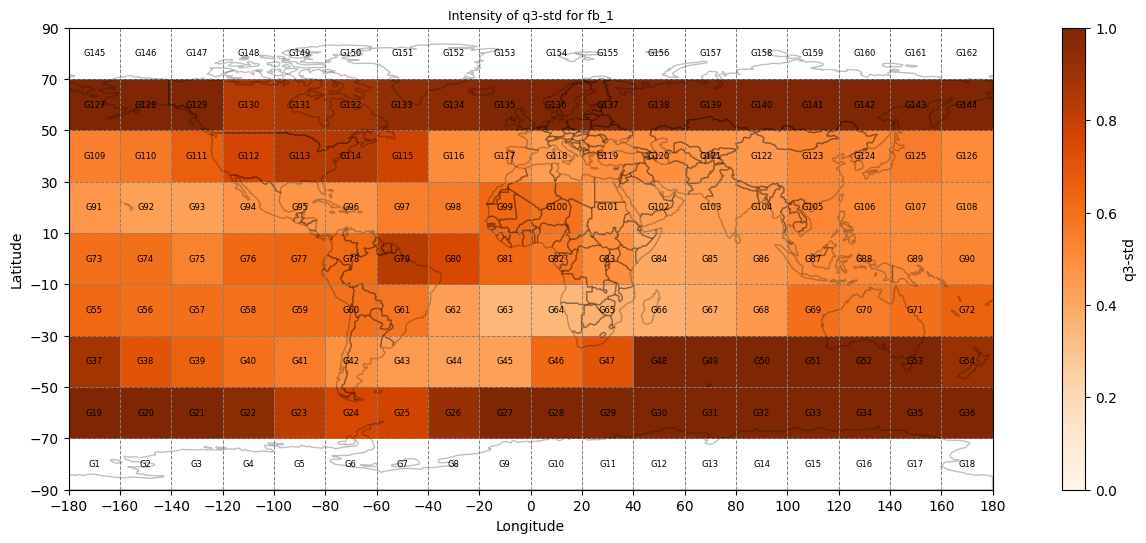

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


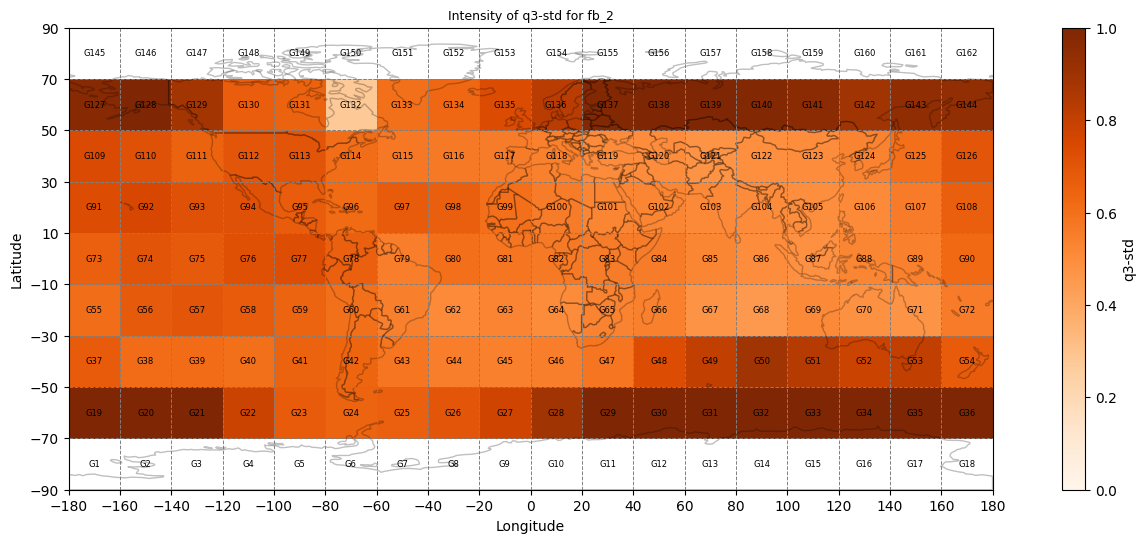

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


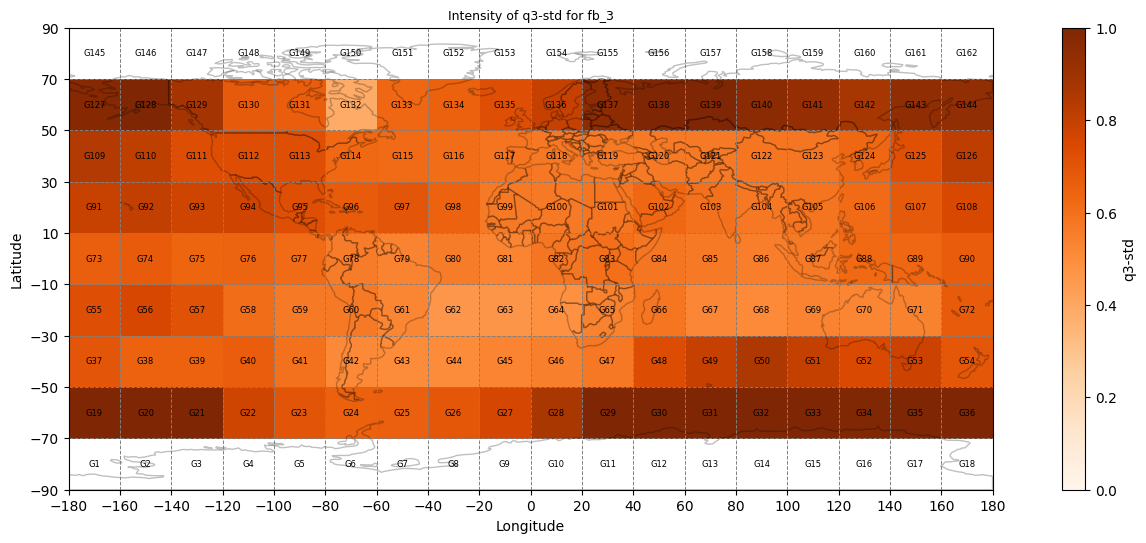

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


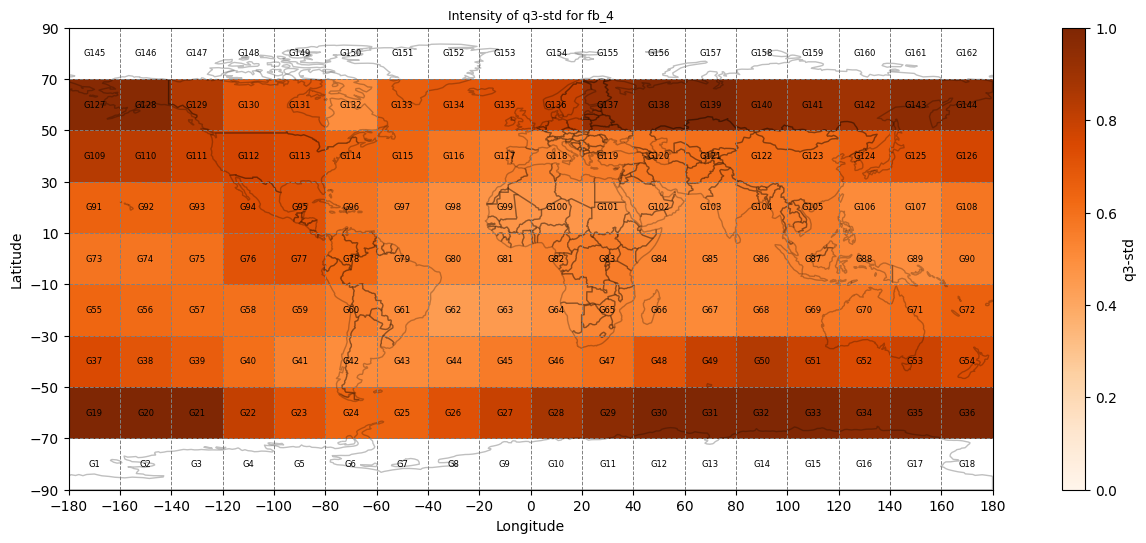

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


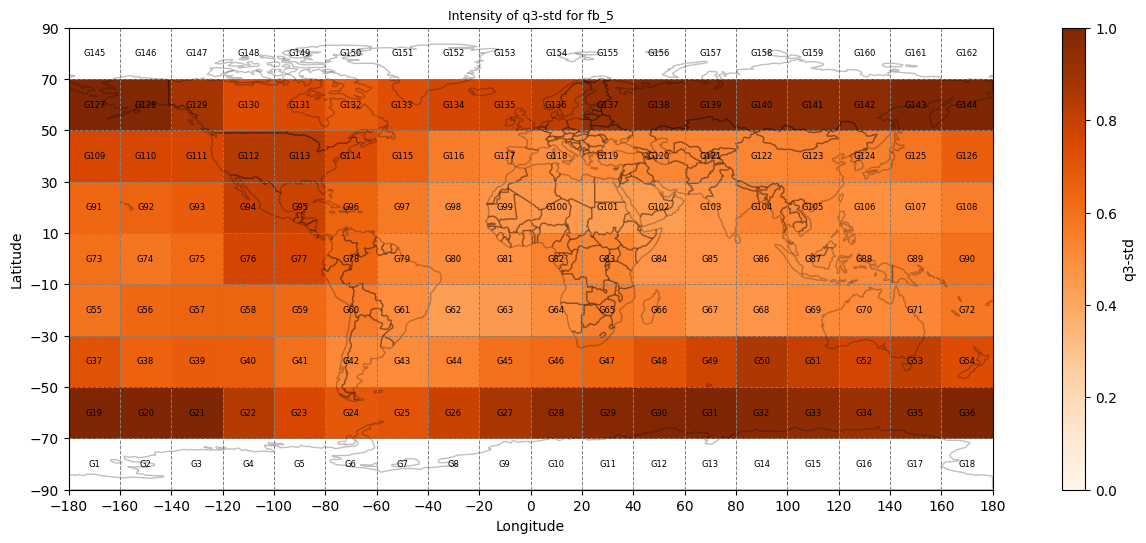

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


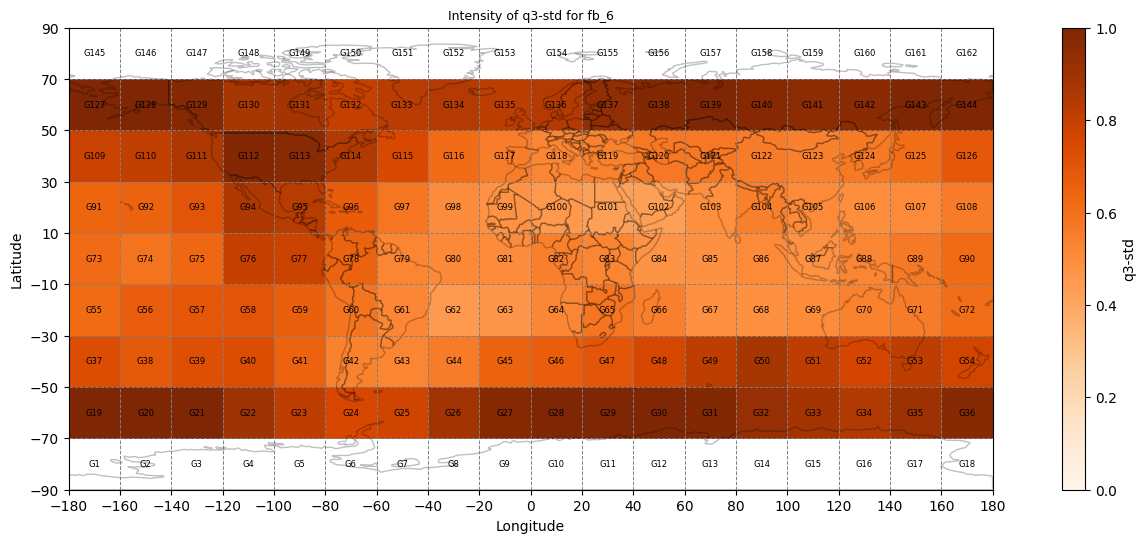

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


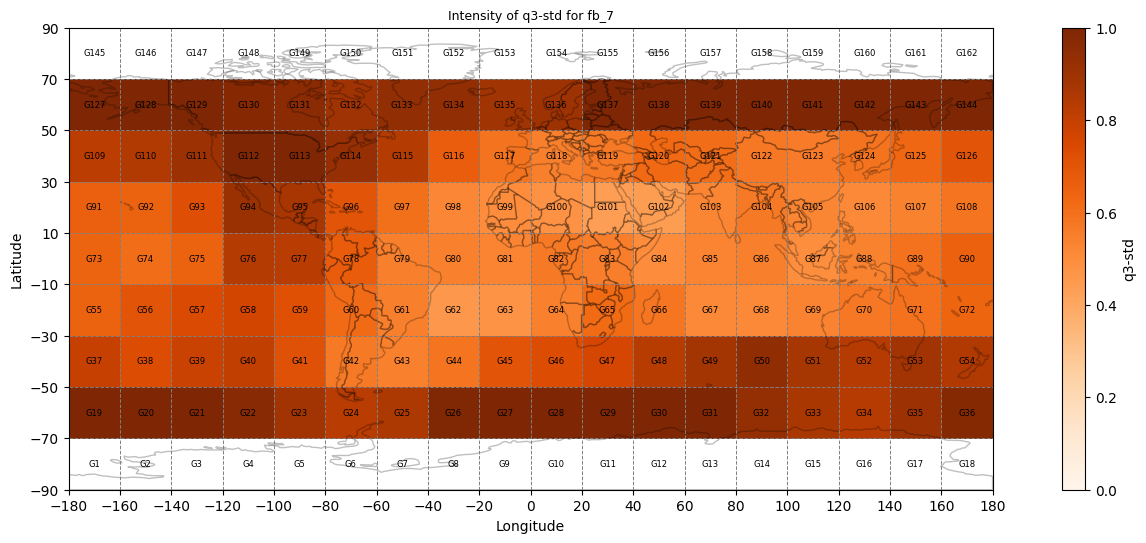

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


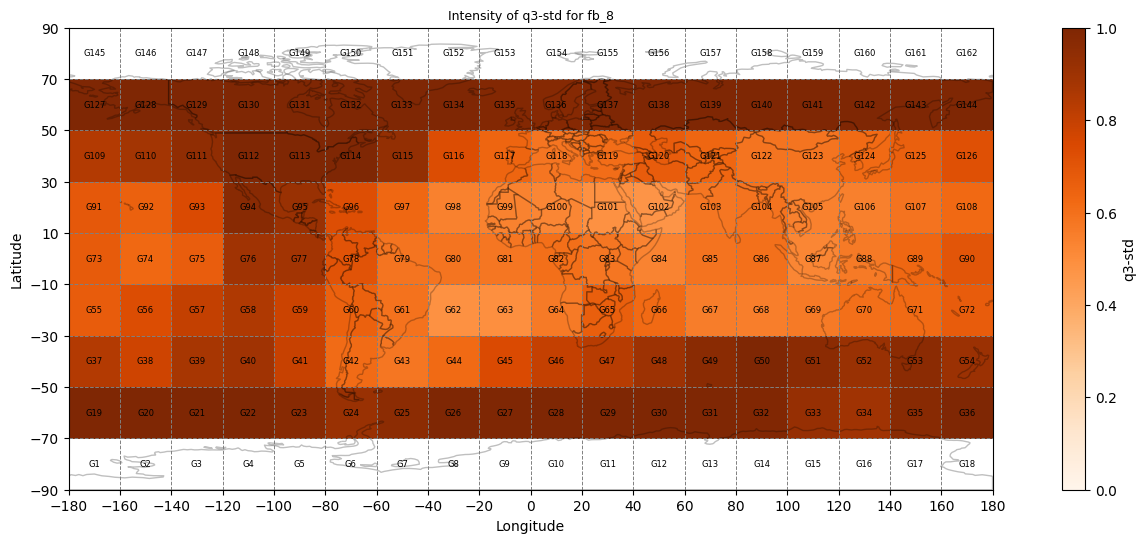

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


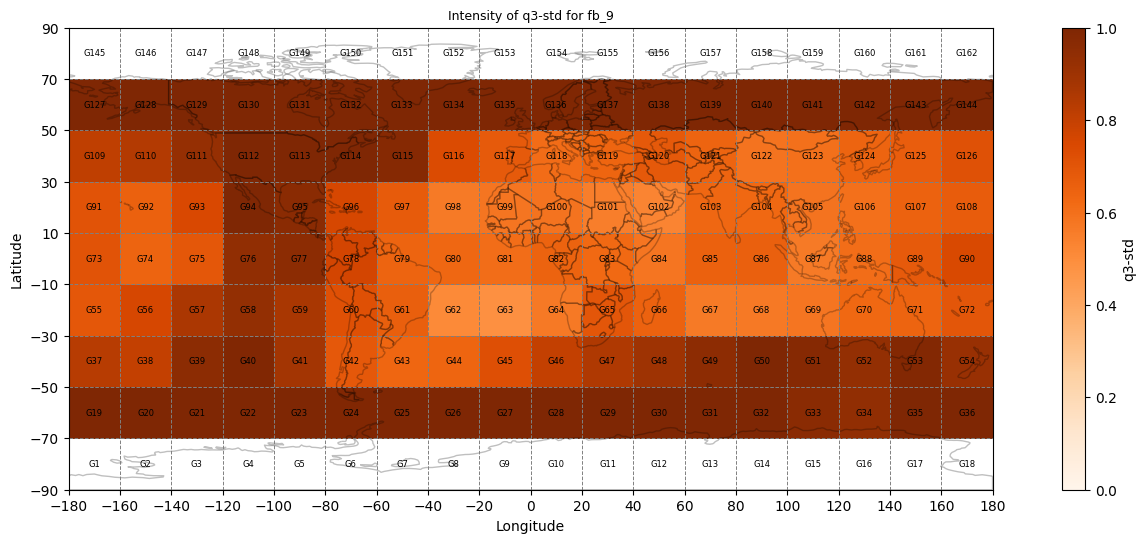

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


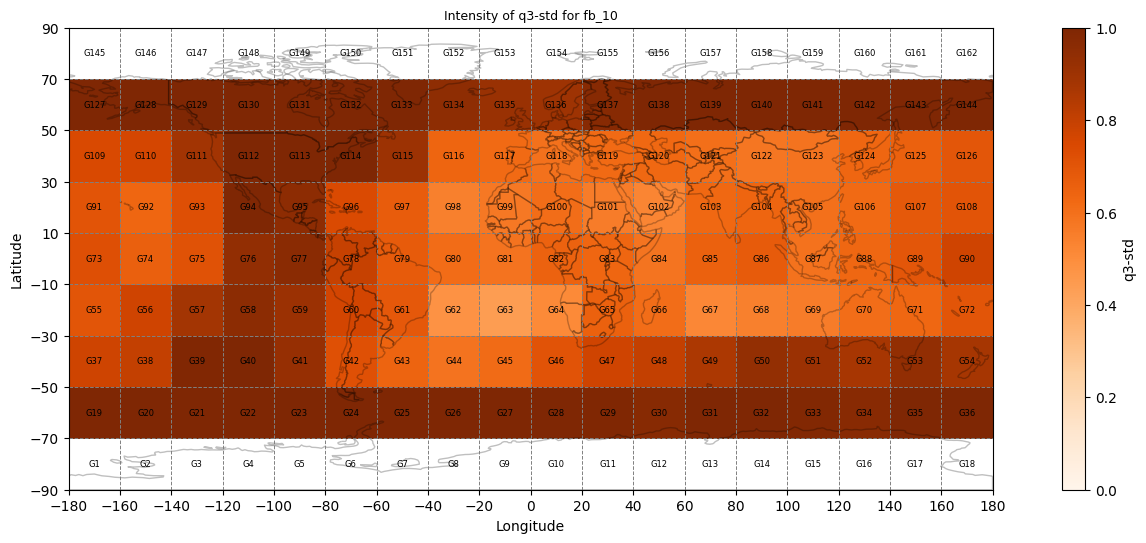

C:\Users\mbabu\AppData\Local\Temp\ipykernel_52160\3645157249.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


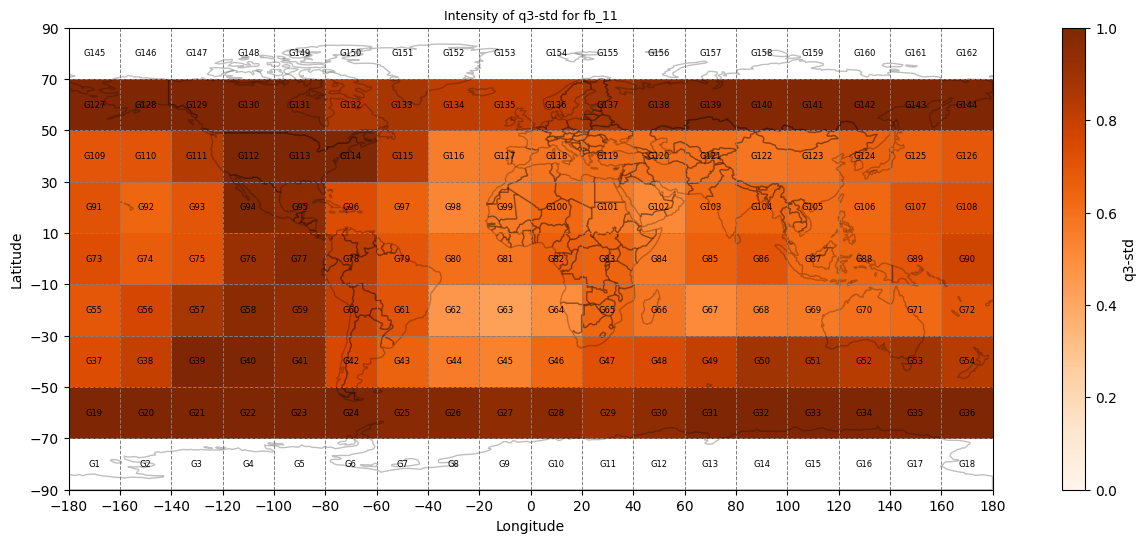

In [23]:


def create_grid(width, depth):
    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)
    
    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'

    return grid


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column, Band_Key):
    fig, ax = plt.subplots(figsize=(18, 6))
    cmap = 'Oranges'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', cmap=cmap, alpha=0.25, zorder=2)
    
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)
    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)
    
    intensities = np.zeros(grid.shape)
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            
            if specific_key in all_data.index:
                intensity = all_data.at[specific_key, intensity_column]  # Use .at[] for a single value
                intensities[lat_idx, lon_idx] = intensity
            else:
                intensities[lat_idx, lon_idx] = np.nan  # Assign NaN if specific_key not found

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')
    im.set_clim(vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)
    
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)
    
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    
    ax.set_title(f'Intensity of {intensity_column} for {Band_Key}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    folder_path = r"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Params_Heatmap"
    os.makedirs(folder_path, exist_ok=True)
    
    plt.savefig(os.path.join(folder_path, f'{Band_Key}_{intensity_column}.png'),dpi =300)
    plt.show()

# Assuming your DataFrame is named df_corr
df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\GRID-FB-UP_ICE-distribution.csv')  # Replace with your actual DataFrame loading code

skip_ranges = [(1, 18), (145, 162)]
fdf = df_corr[~df_corr['specific_key'].str[1:].astype(int).between(1, 18) & ~df_corr['specific_key'].str[1:].astype(int).between(145, 162)]
fdf.reset_index(drop=True, inplace=True)

unique_band_keys = fdf['band_key'].unique()
grid = create_grid(20, 20)

for Band_Key in unique_band_keys:
    new_df = fdf[fdf['band_key'] == Band_Key]
    new_df = new_df[['specific_key', 'band_key',
                     'q1-mean', 'q2-mean', 'q3-mean', 'max-mean',
                     'q1-median', 'q2-median', 'q3-median', 'max-median',
                     'q1-rmsq', 'q2-rmsq', 'q3-rmsq', 'max-rmsq',
                     'q1-std', 'q2-std', 'q3-std', 'max-std']].set_index('specific_key')
    # print(new_df)

    plot_grid_with_intensity(grid, 20, 20, new_df, 'q3-std', Band_Key)
